In [9]:
%load_ext autoreload
%autoreload 2

import numpy as np
import time
import pinocchio as pin
from pinocchio.visualize import MeshcatVisualizer
from meshcat.transformations import translation_matrix, rotation_matrix
from meshcat.geometry import Box, MeshPhongMaterial, Cylinder, Sphere
from prm_motion_planner import MotionPlanner

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Visualization

In [10]:
# specify a path the the urdf files and meshes
urdf_model_path = "diffdrive.urdf"
mesh_dir = ""

# load the robot using pinocchio
robot = pin.RobotWrapper.BuildFromURDF(urdf_model_path, mesh_dir)

# vizualize the robot using meshcat
viz = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
viz.initViewer(loadModel=True)

def show_robot(x,y,theta):
    quat = pin.Quaternion(pin.utils.rotate('z', theta)).coeffs()
    pos = np.array([x,y,0.1])

    viz.display(np.append(pos,quat))

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7003/static/


In [11]:
# define world
grid_size = 10
obstacle_radius = 0.2
min_val, max_val = -grid_size/2, grid_size/2

start = np.array([0.0, 0.0, 0.0]) # x, y, theta
goal = np.array([4.5, 4.0, 0.0])

In [12]:
# Add a floor
# Add floor material
material_floor = MeshPhongMaterial()
material_floor.color = int(200) * 256**2 + int(200) * 256 + int(200)
# Add a floor
viz.viewer["/Floor"].set_object(
    Box([grid_size, grid_size, 0.01]),
    material_floor
)
viz.viewer["/Floor"].set_transform(
    translation_matrix([0, 0, -0.005])
)

material_goal = MeshPhongMaterial()
material_goal.color = int(255) * 256**2 + int(0) * 256 + int(0)

viz.viewer["/Goal"].set_object(
    Sphere(0.15),
    material_goal
)

viz.viewer["/Goal"].set_transform(
    translation_matrix([goal[0], goal[1], 0.15])
)

# Add obstacle material
material_obstacle = MeshPhongMaterial()
material_obstacle.color = int(100) * 256**2 + int(100) * 256 + int(100)

# Randomly generate 30 obstacle positions within a defined range
np.random.seed(6) #6
obstacle_positions = [
    np.array([np.random.uniform(-4.8, 4.8), np.random.uniform(-4.8, 4.8), 0.5])
    
    
    for _ in range(10)
]

# add cylinders for each obstacle
for i, pos in enumerate(obstacle_positions):
    viz.viewer[f"/Obstacle_{i}"].set_object(
        Cylinder(1, obstacle_radius), material_obstacle
    )
    T_world_obs = translation_matrix(pos)
    T_world_obs[:3, :3] = pin.utils.rotate('x', np.pi / 2)
    viz.viewer[f"/Obstacle_{i}"].set_transform(
        T_world_obs
    )

wall_obstacles = []
for i, pos in enumerate(obstacle_positions[::2]):
    # Connect a wall (box) between the two obstacles
    wall_length = np.linalg.norm(obstacle_positions[2*i][:2] - obstacle_positions[2*i+1][:2])
    wall_width = 2*obstacle_radius
    wall_height = 1.0
    wall_material = MeshPhongMaterial()
    wall_material.color = int(100) * 256**2 + int(100) * 256 + int(100)

    p1 = obstacle_positions[2*i][:2]
    p2 = obstacle_positions[2*i+1][:2]

    wall_position = (p1 + p2) / 2

    wall_obstacles.append({
        "p1": p1,
        "p2": p2,
        "wall_width": wall_width
    })

    viz.viewer[f"/Wall_Obstacle_{i}"].set_object(
        Box([wall_length, wall_width, wall_height]), wall_material
    )
    # Set the wall rotation to align with the line between the two obstacles
    angle = np.arctan2(
        obstacle_positions[2*i+1][1] - obstacle_positions[2*i][1],
        obstacle_positions[2*i+1][0] - obstacle_positions[2*i][0]
    )
    viz.viewer[f"/Wall_Obstacle_{i}"].set_transform(
        translation_matrix([wall_position[0], wall_position[1], wall_height / 2]) @
        rotation_matrix(angle, [0, 0, 1])
    )

# Add walls around the floor
wall_thickness = 0.1
wall_height = 1.0

# Left wall
viz.viewer["/Wall_Left"].set_object(Box([wall_thickness, 10, wall_height]))
viz.viewer["/Wall_Left"].set_transform(
    translation_matrix([-5 - wall_thickness / 2, 0, wall_height / 2])
)

# Right wall
viz.viewer["/Wall_Right"].set_object(Box([wall_thickness, 10, wall_height]))
viz.viewer["/Wall_Right"].set_transform(
    translation_matrix([5 + wall_thickness / 2, 0, wall_height / 2])
)

# Front wall
viz.viewer["/Wall_Front"].set_object(Box([10, wall_thickness, wall_height]))
viz.viewer["/Wall_Front"].set_transform(
    translation_matrix([0, 5 + wall_thickness / 2, wall_height / 2])
)

# Back wall
viz.viewer["/Wall_Back"].set_object(Box([10, wall_thickness, wall_height]))
viz.viewer["/Wall_Back"].set_transform(
    translation_matrix([0, -5 - wall_thickness / 2, wall_height / 2])
)

# can you add a tower in each corner of the walls?
tower_height = 1.5
tower_radius = 0.3
tower_material = MeshPhongMaterial()
tower_material.color = int(100) * 256**2 + int(100) * 256 + int(100)

tower_positions = [
    np.array([-5 - wall_thickness / 2, 5 + wall_thickness / 2, tower_height / 2]),
    np.array([5 + wall_thickness / 2, 5 + wall_thickness / 2, tower_height / 2]),
    np.array([-5 - wall_thickness / 2, -5 - wall_thickness / 2, tower_height / 2]),
    np.array([5 + wall_thickness / 2, -5 - wall_thickness / 2, tower_height / 2])
]

for i, pos in enumerate(tower_positions):
    viz.viewer[f"/Tower_{i}"].set_object(
        Cylinder(tower_height, tower_radius), tower_material
    )
    T_world_tower = translation_matrix(pos)
    T_world_tower[:3, :3] = pin.utils.rotate('x', np.pi / 2)
    viz.viewer[f"/Tower_{i}"].set_transform(
        T_world_tower
    )

In [13]:
x,y,theta = 0,0,0
show_robot(x,y,theta)

## Motion Planning

In [14]:
planner = MotionPlanner(
    start=start,
    goal=goal,
    obstacles=wall_obstacles,
    grid_size=grid_size,
    obstacle_radius=obstacle_radius,
    robot_radius=0.3
)

if planner.is_collision(goal):
    raise ValueError("Goal is in collision! Please choose a different goal position.")

path = planner.prm(N=100, k=5)

[(np.float64(6.020797289396148), 100)]
Goal found


### Simulation

In [15]:
# Define robot dynamics
def discrete_dynamics(state, control_input, dt, model_mismatch=False):
    """
    Update the robot's state based on its dynamics.

    Parameters:
    - state: Current state [x, y, theta]
    - control_input: Control input [linear_velocity, angular_velocity]
    - dt: Time step

    Returns:
    - Updated state [x, y, theta]
    """
    x, y, theta = state
    linear_velocity, angular_velocity = control_input
    if model_mismatch:
        # Introduce model mismatch by adding noise to the control input
        linear_velocity += np.random.normal(0, 0.05) # Noise (0, 1.0)
        angular_velocity += np.random.normal(0, 0.05)

    # Update state using differential drive kinematics
    x += linear_velocity * np.cos(theta) * dt
    y += linear_velocity * np.sin(theta) * dt
    theta += angular_velocity * dt

    # Normalize theta to keep it within [-pi, pi]
    theta = np.arctan2(np.sin(theta), np.cos(theta))

    return np.array([x, y, theta])


In [16]:
def simulation(controller):
    # Simulation parameters
    radius = 1.0  # Radius of the circle
    linear_velocity = 1.5  # Linear velocity (m/s)
    angular_velocity = -linear_velocity / radius  # Angular velocity (rad/s)
    dt = 0.01  # Time step (s)
    simulation_time = 20  # Total simulation time (s)
    sensor_noise_stddev = 0.03  # Standard deviation of sensor noise (m)

    # Initial robot position and orientation
    x, y, theta = 0.0, 0.0, 0.0  # Initial position (x, y) and orientation (theta)

    # Simulation loop
    for t in np.arange(0, simulation_time, dt):

        z = np.array([x,y]) + np.random.normal(0, sensor_noise_stddev, 2)  # Simulated sensor measurement with noise

        # calculate control inputs
        u,w = controller(x,y,theta,z)

        # Update robot position and orientation using differential drive kinematics
        x, y, theta = discrete_dynamics([x, y, theta], [u,w], dt, model_mismatch=False)

        # Normalize theta to keep it within [-pi, pi]
        theta = np.arctan2(np.sin(theta), np.cos(theta))

        # Display the robot in the visualization
        show_robot(x, y, theta)
        # Calculate and visualize distances to towers

        # Pause to simulate real-time visualization
        time.sleep(dt)

In [ ]:
path_index = 0

def controller(x, y, theta, z):
    global path_index

    if path_index >= len(path):
        return 0.0, 0.0

    pos = np.array([x, y])
    target = path[path_index]

    waypoint_tolerance = 0.25

    if np.linalg.norm(target - pos) < waypoint_tolerance:
        path_index += 1
        if path_index >= len(path):
            return 0.0, 0.0
        target = path[path_index]

    desired_theta = np.arctan2(target[1] - y, target[0] - x)

    angle_error = np.arctan2(
        np.sin(desired_theta - theta),
        np.cos(desired_theta - theta)
    )

    angular_velocity = 2.0 * angle_error

    # Slow down when not facing the target
    linear_velocity = 0.6 * max(0.0, np.cos(angle_error))

    return linear_velocity, angular_velocity

In [ ]:
simulation(controller)

In [24]:
class EKF:
    def __init__(self, x0, y0, theta0):
        # initial state estimate
        self.x = np.array([x0, y0, theta0])
        
        # initial covariance - high uncertainty in theta since GPS doesn't measure it
        self.P = np.diag([0.1, 0.1, 1.0])
        
        # process noise covariance Q - how much we trust the dynamics model
        # higher = less trust in model, more trust in measurements
        # self.Q = np.diag([0.1, 0.1, 0.1])
        # manual tuning:
        # self.Q = np.diag([0.5, 0.5, 0.1])   # large process noise due to model mismatch
        # removing self.Q, going to use Jacobian Q
        
        # measurement noise covariance R - from simulation: noise std = 0.03
        self.R = np.diag([0.0009, 0.0009])
        
        # measurement matrix H - GPS measures x and y only
        self.H = np.array([[1, 0, 0],
                           [0, 1, 0]])

    def predict(self, u, w, dt):
        x, y, theta = self.x
        
        # propagate state using differential drive dynamics
        self.x = np.array([
            x + u * np.cos(theta) * dt,
            y + u * np.sin(theta) * dt,
            np.arctan2(np.sin(theta + w * dt), np.cos(theta + w * dt))  # normalize
        ])
        
        # jacobian of dynamics w.r.t. state (linearization)
        A = np.array([
            [1, 0, -u * np.sin(theta) * dt],
            [0, 1,  u * np.cos(theta) * dt],
            [0, 0,  1]
        ])

        #------------------------------------------------------
        # jacobian of dynamics w.r.t. control inputs [u, w]
        B = np.array([
            [np.cos(theta) * dt,  0],
            [np.sin(theta) * dt,  0],
            [0,                   dt]
        ])

        # control noise covariance, std=1.0 on both u and w from model mismatch
        Q_control = np.diag([1.0**2, 1.0**2])
    
        # propagate control noise through dynamics
        Q = B @ Q_control @ B.T

        # to fix NEES, add small additional uncertainty
        # Q += np.diag([0.000001, 0.000001, 0.000005])
        # rather continue with pure Jacobian Q, can be tunned manually if needed later
        #-------------------------------------------------------
        
        # propagate covariance
        # self.P = A @ self.P @ A.T + self.Q  # with manual self.Q
        self.P = A @ self.P @ A.T + Q         # with Jacobian Q  
    
    def update(self, z):
        # innovation: difference between measurement and prediction
        nu = z - self.H @ self.x
        
        # innovation covariance
        self.S = self.H @ self.P @ self.H.T + self.R
        
        # kalman gain
        K = self.P @ self.H.T @ np.linalg.inv(self.S)
        
        # update state and covariance
        self.x = self.x + K @ nu
        self.x[2] = np.arctan2(np.sin(self.x[2]), np.cos(self.x[2]))  # normalize theta
        self.P = (np.eye(3) - K @ self.H) @ self.P

    def get_state(self):
        return self.x

In [25]:
# initialize EKF once before simulation
ekf = EKF(x0=0.0, y0=0.0, theta0=0.0)
dt = 0.01  # must match simulation dt

In [26]:
# def controller(x,y,theta,z):
#     return 2, -2

# create storage
history = {'gps_x': [], 'gps_y': [], 
           'ekf_x': [], 'ekf_y': [], 'ekf_theta': [],
           'true_x': [], 'true_y': [], 'true_theta': [],
           'P': [], 'S': []}

def controller_with_ekf(x, y, theta, z):
    # controller currently uses true values, later use x_est, y_est, theta_est
    # EKF predict step uses last control input
    # we use fixed inputs here same as dummy controller
    u, w = 2, -2
    
    ekf.predict(u, w, dt)  # predict with control inputs
    ekf.update(z)          # correct with GPS measurement
    
    # Use EKF estimate instead of raw state
    x_est, y_est, theta_est = ekf.get_state()

    # store history
    history['gps_x'].append(z[0])
    history['gps_y'].append(z[1])
    history['ekf_x'].append(x_est)
    history['ekf_y'].append(y_est)
    history['ekf_theta'].append(theta_est)
    history['true_x'].append(x)
    history['true_y'].append(y)
    history['true_theta'].append(theta)
    history['P'].append(ekf.P.copy())
    history['S'].append(ekf.S.copy())

    # # ----------------------------------------------
    # # check
    # if not hasattr(controller_with_ekf, 'step'):
    #     controller_with_ekf.step = 0
    # controller_with_ekf.step += 1
    
    # if controller_with_ekf.step % 100 == 0:
    #     print(f"GPS raw:  x={z[0]:.3f}, y={z[1]:.3f}")
    #     print(f"EKF est: x={x_est:.3f}, y={y_est:.3f}, theta={theta_est:.3f}")
    #     print(f"True:     x={x:.3f}, y={y:.3f}, theta={theta:.3f}")
    #     print("---")
    # # ----------------------------------------------

    return u, w


In [ ]:
simulation(controller_with_ekf)

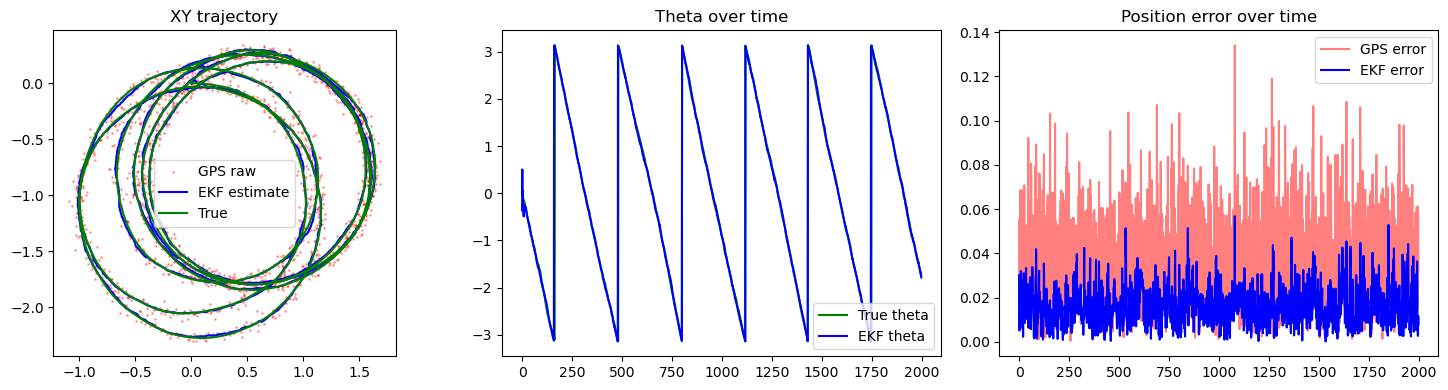

In [28]:
# -----------------------------------------------------------------
# plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['gps_x'], history['gps_y'], 'r.', alpha=0.3, markersize=2, label='GPS raw')
axes[0].plot(history['ekf_x'], history['ekf_y'], 'b-', linewidth=1.5, label='EKF estimate')
axes[0].plot(history['true_x'], history['true_y'], 'g-', linewidth=1.5, label='True')
axes[0].set_title('XY trajectory')
axes[0].legend()
axes[0].set_aspect('equal')

axes[1].plot(history['true_theta'], 'g-', label='True theta')
axes[1].plot(history['ekf_theta'], 'b-', label='EKF theta')
axes[1].set_title('Theta over time')
axes[1].legend()

# position error
ekf_err = np.sqrt((np.array(history['ekf_x']) - np.array(history['true_x']))**2 + 
                  (np.array(history['ekf_y']) - np.array(history['true_y']))**2)
gps_err = np.sqrt((np.array(history['gps_x']) - np.array(history['true_x']))**2 + 
                  (np.array(history['gps_y']) - np.array(history['true_y']))**2)

axes[2].plot(gps_err, 'r-', alpha=0.5, label='GPS error')
axes[2].plot(ekf_err, 'b-', label='EKF error')
axes[2].set_title('Position error over time')
axes[2].legend()

plt.tight_layout()
plt.show()
# -----------------------------------------------------------------

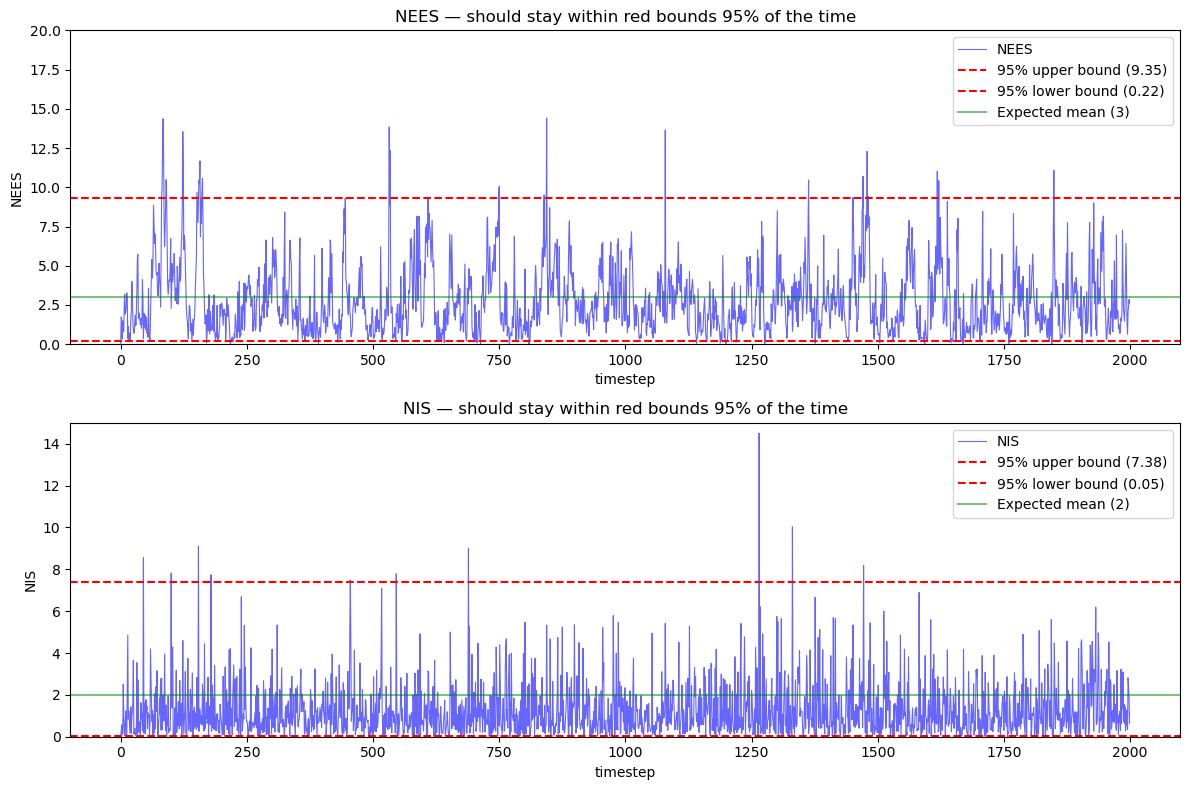

NEES: 96.0% of values within 95% bounds (expect ~95%)
NIS:  95.6% of values within 95% bounds (expect ~95%)
Mean NEES: 2.79 (expect ~3)
Mean NIS:  1.27  (expect ~2)


In [29]:
from scipy.stats import chi2

# -------------------------------------------------------------------------------
# compute NEES and NIS
nees_values = []
nis_values  = []

for i in range(len(history['true_x'])):
    # --- NEES ---
    x_true = np.array([history['true_x'][i], 
                       history['true_y'][i], 
                       history['true_theta'][i]])
    x_est  = np.array([history['ekf_x'][i], 
                       history['ekf_y'][i], 
                       history['ekf_theta'][i]])
    P      = history['P'][i]          # covariance at each step (we need to store this)
    
    x_tilde = x_true - x_est
    # normalize theta error to [-pi, pi]
    x_tilde[2] = np.arctan2(np.sin(x_tilde[2]), np.cos(x_tilde[2]))
    
    nees = x_tilde @ np.linalg.inv(P) @ x_tilde
    nees_values.append(nees)
    
    # --- NIS ---
    z     = np.array([history['gps_x'][i], history['gps_y'][i]])
    x_bar = np.array([history['ekf_x'][i], history['ekf_y'][i]])  
    # innovation
    nu    = z - x_bar   # H @ x_est = x_est[:2] since H picks first two states
    S     = history['S'][i]           # innovation covariance at each step
    
    nis = nu @ np.linalg.inv(S) @ nu
    nis_values.append(nis)

nees_values = np.array(nees_values)
nis_values  = np.array(nis_values)

# chi-squared bounds 
# 95% confidence interval
n = 3   # state dimensions  -> NEES ~ chi2(3)
m = 2   # measurement dimensions -> NIS ~ chi2(2)

nees_lower = chi2.ppf(0.025, df=n)   # 2.5th percentile
nees_upper = chi2.ppf(0.975, df=n)   # 97.5th percentile
nis_lower  = chi2.ppf(0.025, df=m)
nis_upper  = chi2.ppf(0.975, df=m)

# plot
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(nees_values, 'b-', alpha=0.6, linewidth=0.8, label='NEES')
axes[0].axhline(nees_upper, color='r', linestyle='--', label=f'95% upper bound ({nees_upper:.2f})')
axes[0].axhline(nees_lower, color='r', linestyle='--', label=f'95% lower bound ({nees_lower:.2f})')
axes[0].axhline(n, color='g', linestyle='-', alpha=0.5, label=f'Expected mean ({n})')
axes[0].set_title('NEES — should stay within red bounds 95% of the time')
axes[0].set_ylabel('NEES')
axes[0].set_xlabel('timestep')
axes[0].legend()
axes[0].set_ylim(0, 20)

axes[1].plot(nis_values, 'b-', alpha=0.6, linewidth=0.8, label='NIS')
axes[1].axhline(nis_upper, color='r', linestyle='--', label=f'95% upper bound ({nis_upper:.2f})')
axes[1].axhline(nis_lower, color='r', linestyle='--', label=f'95% lower bound ({nis_lower:.2f})')
axes[1].axhline(m, color='g', linestyle='-', alpha=0.5, label=f'Expected mean ({m})')
axes[1].set_title('NIS — should stay within red bounds 95% of the time')
axes[1].set_ylabel('NIS')
axes[1].set_xlabel('timestep')
axes[1].legend()
axes[1].set_ylim(0, 15)

plt.tight_layout()
plt.show()

# print summary
pct_nees_in = np.mean((nees_values >= nees_lower) & (nees_values <= nees_upper)) * 100
pct_nis_in  = np.mean((nis_values  >= nis_lower)  & (nis_values  <= nis_upper))  * 100

print(f"NEES: {pct_nees_in:.1f}% of values within 95% bounds (expect ~95%)")
print(f"NIS:  {pct_nis_in:.1f}% of values within 95% bounds (expect ~95%)")
print(f"Mean NEES: {nees_values.mean():.2f} (expect ~{n})")
print(f"Mean NIS:  {nis_values.mean():.2f}  (expect ~{m})")
# -------------------------------------------------------------------------------